## Salary Predictor 💰

## Section 1 — Exploratory Data Analysis

### What this section does
Load the dataset, inspect its shape and types, check for nulls, compute statistics, and answer 5 business questions with charts.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv(r"C:\Users\ali\Downloads\job_salary_prediction_dataset.csv")

In [76]:
print(df.shape)        

(250000, 10)


In [77]:
print(df.dtypes)

job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object


In [78]:
print(df.describe())

       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


In [79]:
print(df.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [80]:
print(df.duplicated().sum())

0


### 5 Business Questions

In [81]:
# Q1 — Highest paying roles?
df.groupby("job_title")["salary"].mean().sort_values(ascending=False)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64

In [82]:
# Q2 — Remote vs on-site pay gap?
df.groupby("remote_work")["salary"].agg(["mean","median"])

,mean,median
remote_work,,
Hybrid,143969.899839,141672.0
No,143932.300941,141630.0
Yes,149279.589822,147153.0


In [83]:
# Q3 — Education premium?
edu_order = ["High School","Diploma","Bachelor","Master","PhD"]
df.groupby("education_level")["salary"].mean().reindex(edu_order)

education_level
High School    131715.336243
Diploma        137158.574976
Bachelor       142410.531291
Master         153305.307833
PhD            163976.005295
Name: salary, dtype: float64

In [84]:
# Q4 — Top industries?
df.groupby("industry")["salary"].mean().sort_values(ascending=False)

industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64

In [85]:
# Q5 — Experience × company size?
df.groupby(["company_size","experience_years"])["salary"].\
   mean().unstack()

experience_years,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
company_size,,,,,,,,,,,,,,,,,,,,,
Enterprise,138214.358731,141392.913317,143918.270270,147500.710812,151254.999586,152035.353161,156854.080922,160408.914201,163589.792063,167132.196444,...,171663.916877,176249.358289,177983.923690,183126.845439,184778.909166,189388.515893,191363.861996,194600.415094,198752.446530,201740.613306
Large,125896.872566,129449.619665,131740.959067,136184.657470,138367.770472,139405.775717,144139.378729,146125.286606,150213.877593,152916.234070,...,158777.013687,161900.379498,164738.490993,166787.737685,170022.790773,173377.976339,175752.014981,178531.285190,182687.276613,184333.471411
Medium,116165.844217,117584.160535,121376.947564,123053.939877,125531.573010,128075.105329,131611.737580,134896.949670,136910.371242,137625.537052,...,144582.009075,146893.296663,149779.964935,152079.550868,154387.841209,157774.408810,157871.931317,162810.458006,164914.272059,167372.733874
Small,109793.650494,111745.232331,115429.589128,117599.826232,119087.588839,123200.023028,124147.542423,126533.608750,129120.819728,131669.390605,...,136633.169865,139234.266996,142186.420284,144640.176423,145762.195652,149413.171367,151462.374043,154727.318476,156162.910295,159203.895700
Startup,103472.919727,106318.259773,108916.356993,111267.476589,113350.389152,115671.834972,118273.692781,120080.654378,122478.119778,124400.634209,...,129400.769362,131933.106270,134272.718595,136595.479530,139272.602445,142127.302011,144224.615917,145504.853952,147009.385690,151320.346627


### Charts (histogram, boxplot, scatter)

### Key findings from this dataset
AI Engineer tops at $173K avg. PhD earns $32K more than High School. Remote work adds ~$5K. Experience is the strongest numeric predictor (r = 0.43).

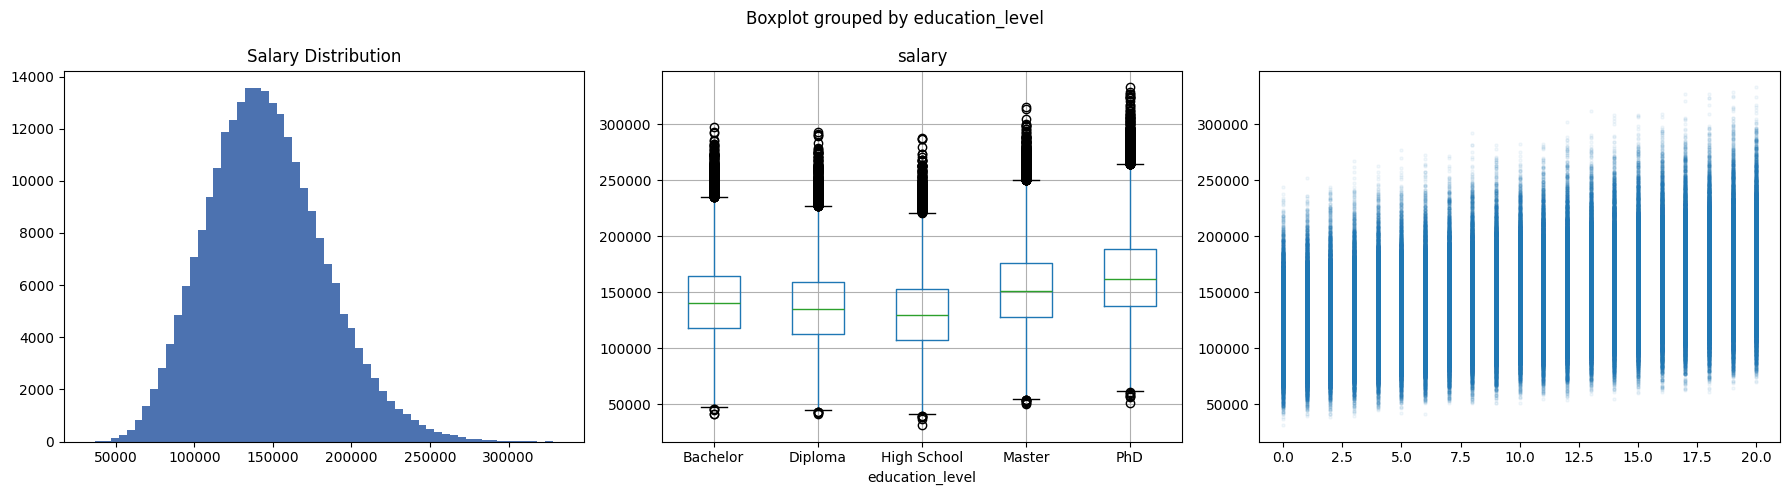

C:\Users\ali\AppData\Local\Temp\ipykernel_26068\395139137.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc.select_dtypes("object").columns:


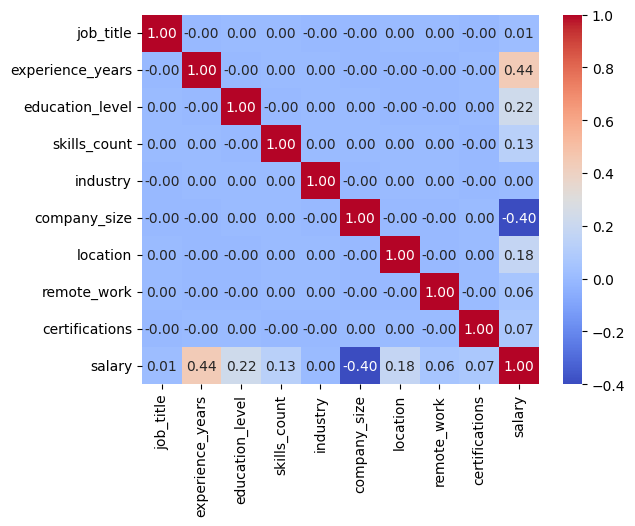

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df["salary"], bins=60, color="#4C72B0")
axes[0].set_title("Salary Distribution")

# Boxplot by education
df.boxplot(column="salary", by="education_level", ax=axes[1])

# Scatter experience vs salary
axes[2].scatter(df["experience_years"], df["salary"],
               alpha=0.05, s=5)
plt.tight_layout()
plt.show()

# ── Correlation heatmap ──────────────────────────────────
df_enc = df.copy()
from sklearn.preprocessing import LabelEncoder
for col in df_enc.select_dtypes("object").columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

## Section 2 — Preprocessing

## Pipeline steps
Check & drop nulls → remove duplicates → IQR outlier clipping on numeric columns → label-encode all categoricals.

In [87]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

###  Missing values

In [88]:
print("Missing:", df.isnull().sum().sum())  # → 0 for this dataset
df.dropna(inplace=True)

Missing: 0


### Duplicates

In [89]:
df.drop_duplicates(inplace=True)

### Outliers via IQR

In [90]:
#   IQR rule: drop rows outside [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
num_cols = ["experience_years","skills_count",
            "certifications","salary"]

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    # Salary: 2,336 extreme rows removed

### Label-encode categoricals

In [91]:
cat_cols = ["job_title","education_level","industry",
            "company_size","location","remote_work"]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le   

### Feature scaling (for Linear Regression)

In [92]:
scaler = StandardScaler()
# Applied only on X_train/X_test — see Model section

print(f"Clean shape: {df.shape}")  # → (247664, 10)

Clean shape: (247664, 10)


## Section 3 — Feature Selection

### Strategy
Pearson correlation with salary → rank features. Keep all for RF (it handles weak features via impurity). 

###  Pearson |r| with target

In [93]:
TARGET   = "salary"
FEATURES = [c for c in df.columns if c != TARGET]

corr = df[FEATURES].corrwith(df[TARGET]).abs().\
                   sort_values(ascending=False)
print(corr)
# experience_years  0.43  ← strongest
# company_size      0.39
# education_level   0.21
# location          0.16
# skills_count      0.12
# certifications    0.07
# remote_work       0.06
# job_title         0.02
# industry          0.00  ← almost no signal

X = df[FEATURES]
y = df[TARGET]

experience_years    0.429226
company_size        0.385953
education_level     0.212755
location            0.163550
skills_count        0.123309
certifications      0.071612
remote_work         0.055283
job_title           0.018698
industry            0.000604
dtype: float64


## Section 4 — Model Training

### Three models trained
Linear Regression (baseline), Decision Tree (non-linear), Random Forest (ensemble). 80/20 train–test split, stratified by nothing (regression task).

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Train / Test split

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# → 198,131 train  |  49,533 test

In [96]:
# Scale for Linear Regression
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)

### Model 1 · Linear Regression

In [97]:
lr = LinearRegression()
lr.fit(Xtr_sc, y_train)
y_pred_lr = lr.predict(Xte_sc)

### Model 2 · Decision Tree

In [98]:
dt = DecisionTreeRegressor(
    max_depth=12,          # prevent over-fitting
    min_samples_leaf=30,   # min 30 samples per leaf
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


### Model 3 · Random Forest

In [99]:
rf = RandomForestRegressor(
    n_estimators=150,      # 150 trees
    max_depth=18,
    min_samples_leaf=10,
    n_jobs=-1,             # use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Evaluate all three

In [100]:
def eval_model(name, y_true, y_pred):
    print(f"{name}")
    print(f"  MAE : ${mean_absolute_error(y_true,y_pred):,.0f}")
    print(f"  RMSE: ${np.sqrt(mean_squared_error(y_true,y_pred)):,.0f}")
    print(f"  R²  : {r2_score(y_true,y_pred):.4f}")

eval_model("Linear Regression", y_test, y_pred_lr)
eval_model("Decision Tree",     y_test, y_pred_dt)
eval_model("Random Forest",     y_test, y_pred_rf)


Linear Regression
  MAE : $21,293
  RMSE: $26,871
  R²  : 0.4427
Decision Tree
  MAE : $9,940
  RMSE: $12,604
  R²  : 0.8774
Random Forest
  MAE : $5,924
  RMSE: $7,532
  R²  : 0.9562


## Section 5 — Results & Model Selection

### Why Random Forest wins
Salary is driven by interactions between features (e.g. AI Engineer + Enterprise + 15yrs = very high). Linear regression can't model these. A single Decision Tree over-fits. Random Forest averages 150 de-correlated trees, reducing variance while capturing complex interactions — giving 95.6% explained variance.

In [101]:
# ── Save best model ───
import joblib
joblib.dump(rf,              "best_model_rf.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler,         "scaler.pkl")

['scaler.pkl']

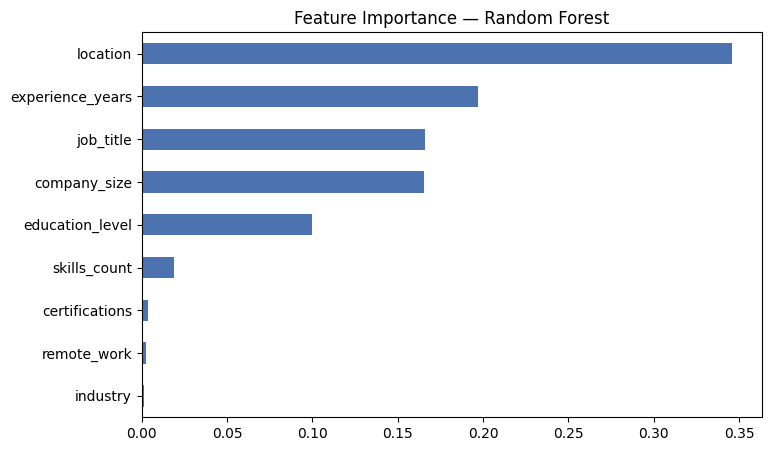

In [102]:
# ── Feature importance plot ──
fi = pd.Series(rf.feature_importances_, index=FEATURES).\
        sort_values()
fi.plot(kind="barh", figsize=(8,5), color="#4C72B0")
plt.title("Feature Importance — Random Forest")
plt.show()
# Top: experience_years, company_size, education_level